In [45]:
import pandas as pd
from matplotlib import pyplot as plt


In [46]:
df = pd.read_csv('../../data/raw/chicago_motor_vehicle_theft_crimes.csv')
df = df[df['Description'] != 'AUTOMOBILE']

In [47]:
df.columns

Index(['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type',
       'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat',
       'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate',
       'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude',
       'Location'],
      dtype='object')

C:\Users\dylan\AppData\Local\Temp\ipykernel_17332\2759502399.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])
C:\Users\dylan\AppData\Local\Temp\ipykernel_17332\2759502399.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  murders_per_month = murders_per_day.resample('M').sum()


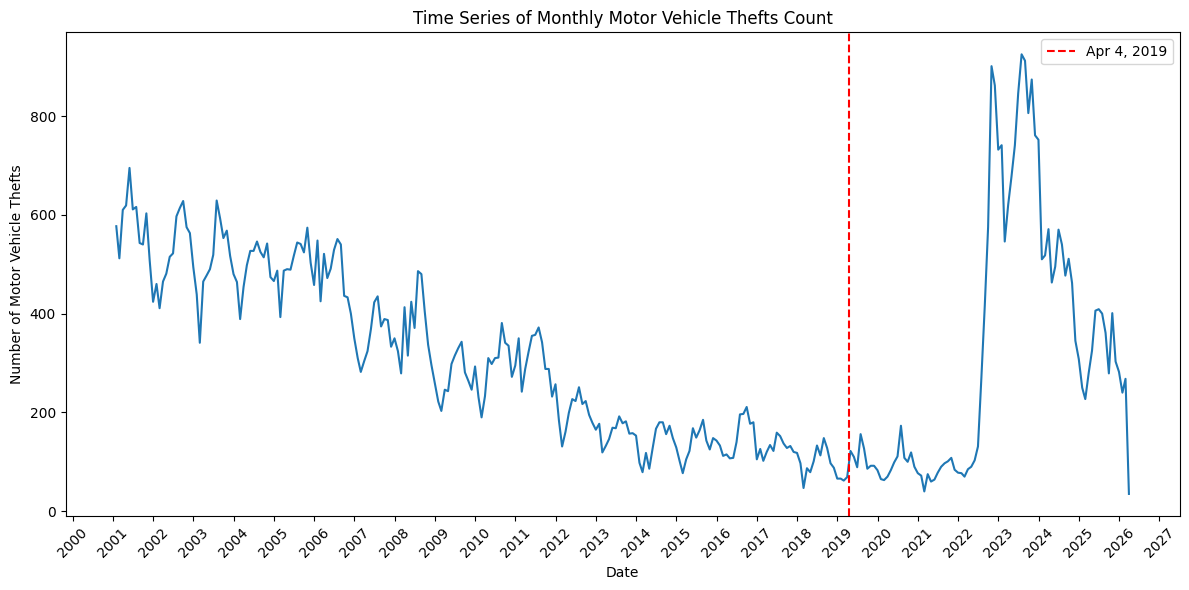

In [48]:
# Convert date column to datetime and sort
df['Date'] = pd.to_datetime(df['Date'])
df_sorted = df.sort_values('Date')

# Count murders per day
murders_per_day = df_sorted.groupby('Date').size()

# Resample to monthly counts
murders_per_month = murders_per_day.resample('M').sum()

# Create the plot (monthly, connected points)
plt.figure(figsize=(12, 6))
plt.plot(murders_per_month.index, murders_per_month.values, linestyle='-')
import matplotlib.dates as mdates
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.axvline(x=pd.to_datetime('2019-04-19'), color='red', linestyle='--', label='Apr 4, 2019')
plt.xlabel('Date')
plt.ylabel('Number of Motor Vehicle Thefts')
plt.title('Time Series of Monthly Motor Vehicle Thefts Count')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\dylan\AppData\Local\Temp\ipykernel_17332\1150667752.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_before = df_before.groupby(pd.Grouper(key='Date', freq='M')).size()
C:\Users\dylan\AppData\Local\Temp\ipykernel_17332\1150667752.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_after = df_after.groupby(pd.Grouper(key='Date', freq='M')).size()


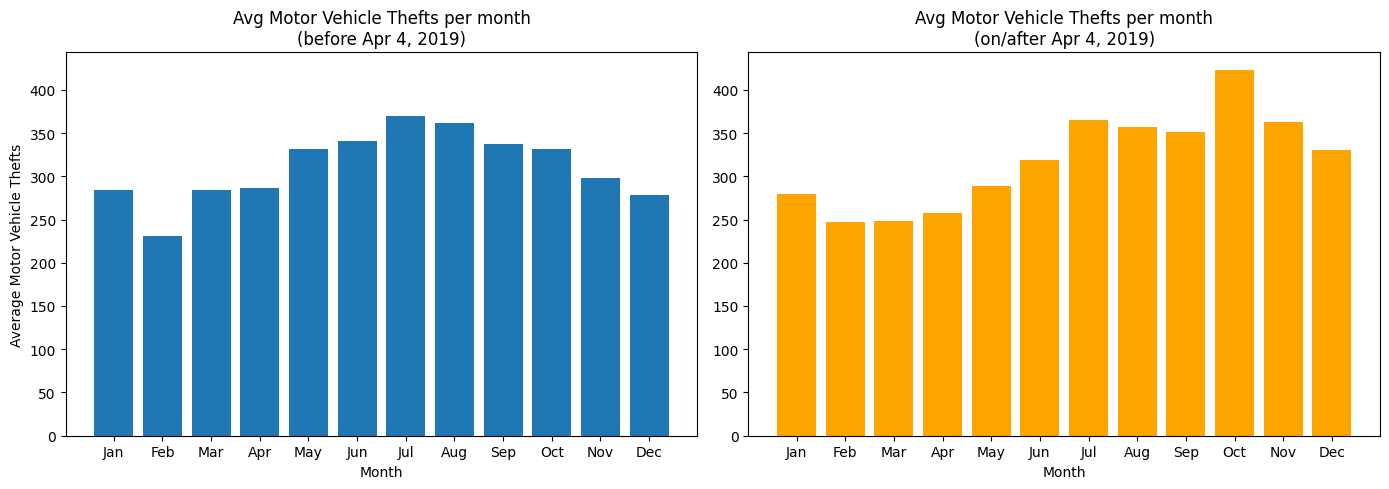

In [49]:
# Compare average murders per calendar month before and after cutoff
cutoff = pd.to_datetime('2019-04-04')
df_before = df_sorted[df_sorted['Date'] < cutoff]
df_after = df_sorted[df_sorted['Date'] >= cutoff]

# Monthly sums for each period
monthly_before = df_before.groupby(pd.Grouper(key='Date', freq='M')).size()
monthly_after = df_after.groupby(pd.Grouper(key='Date', freq='M')).size()

# Average by calendar month (1-12), reindex to ensure all months present
avg_by_month_before = monthly_before.groupby(monthly_before.index.month).mean().reindex(range(1,13), fill_value=0)
avg_by_month_after = monthly_after.groupby(monthly_after.index.month).mean().reindex(range(1,13), fill_value=0)

import calendar
months = [calendar.month_abbr[i] for i in range(1,13)]

plt.figure(figsize=(14,5))
ax1 = plt.subplot(1,2,1)
ax1.bar(months, avg_by_month_before.values)
ax1.set_title('Avg Motor Vehicle Thefts per month\n(before Apr 4, 2019)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Motor Vehicle Thefts')

ax2 = plt.subplot(1,2,2)
ax2.bar(months, avg_by_month_after.values, color='orange')
ax2.set_title('Avg Motor Vehicle Thefts per month\n(on/after Apr 4, 2019)')
ax2.set_xlabel('Month')

# Use the same y-axis scale for both subplots
ymax = max(avg_by_month_before.max(), avg_by_month_after.max())
ax1.set_ylim(0, ymax * 1.05)
ax2.set_ylim(0, ymax * 1.05)

plt.tight_layout()
plt.show()

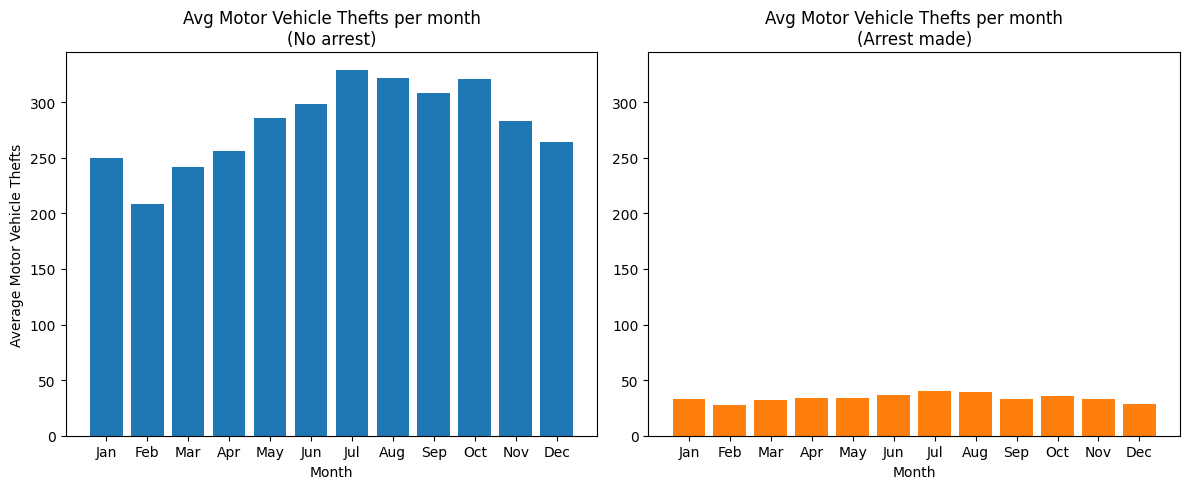

In [50]:


# Average murders per calendar month split by whether an arrest was made
df['Date'] = pd.to_datetime(df['Date'])
df_sorted = df.sort_values('Date')

# Normalize Arrest to boolean (handles True/False, Yes/No, Y/N, 1/0, etc.)
df_sorted['arrest_flag'] = df_sorted['Arrest'].astype(str).str.lower().isin(
    ['true','t','y','yes','1','y','yes'])
labels = {False: 'No arrest', True: 'Arrest made'}

monthly_avg = {}
for flag in [False, True]:
    tmp = df_sorted[df_sorted['arrest_flag'] == flag]
    monthly = tmp.groupby(pd.Grouper(key='Date', freq='ME')).size()
    monthly_avg[flag] = monthly.groupby(monthly.index.month).mean().reindex(range(1,13), fill_value=0)

import calendar
months = [calendar.month_abbr[i] for i in range(1,13)]

plt.figure(figsize=(12,5))
ax1 = plt.subplot(1,2,1)
ax1.bar(months, monthly_avg[False].values, color='C0')
ax1.set_title('Avg Motor Vehicle Thefts per month\n(No arrest)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Motor Vehicle Thefts')

ax2 = plt.subplot(1,2,2)
ax2.bar(months, monthly_avg[True].values, color='C1')
ax2.set_title('Avg Motor Vehicle Thefts per month\n(Arrest made)')
ax2.set_xlabel('Month')

# Use same y-axis scale for both subplots
ymax = max(monthly_avg[False].max(), monthly_avg[True].max())
ax1.set_ylim(0, ymax * 1.05)
ax2.set_ylim(0, ymax * 1.05)

plt.tight_layout()
plt.show()
# ...existing code...

In [51]:
df['Description'].unique()

array(['THEFT / RECOVERY - AUTOMOBILE', 'ATTEMPT - AUTOMOBILE',
       'CYCLE, SCOOTER, BIKE WITH VIN', 'TRUCK, BUS, MOTOR HOME',
       'CYCLE, SCOOTER, BIKE NO VIN', 'ATTEMPT - TRUCK, BUS, MOTOR HOME',
       'THEFT / RECOVERY - CYCLE, SCOOTER, BIKE WITH VIN',
       'ATTEMPT - CYCLE, SCOOTER, BIKE WITH VIN',
       'THEFT / RECOVERY - TRUCK, BUS, MOBILE HOME',
       'ATTEMPT - CYCLE, SCOOTER, BIKE NO VIN',
       'THEFT / RECOVERY - CYCLE, SCOOTER, BIKE NO VIN',
       'THEFT/RECOVERY: AUTOMOBILE', 'ATT: AUTOMOBILE',
       'CYCLE, SCOOTER, BIKE W-VIN', 'THEFT/RECOVERY: TRUCK,BUS,MHOME',
       'ATT: TRUCK, BUS, MOTOR HOME',
       'ATTEMPT: CYCLE, SCOOTER, BIKE W-VIN',
       'THEFT/RECOVERY: CYCLE, SCOOTER, BIKE NO VIN',
       'ATTEMPT: CYCLE, SCOOTER, BIKE NO VIN',
       'THEFT/RECOVERY: CYCLE, SCOOTER, BIKE W-VIN'], dtype=object)